# Milestone 3 — Historical graph comparison
**Joel Cerraga · Market-Neutral Trading Algorithm**

The fixed graph-diffusion strategy is compared with the Milestone 2 baseline under the same observations, timing, constraints and costs. All 44 predeclared backtests are retained. No new primary model is chosen after seeing the results.

As Kondor and Lafferty (2002) explain in *Diffusion Kernels on Graphs and Other Discrete Input Spaces*, a graph's matrix exponential can describe smoothing. Trading the residual is a separate hypothesis that this notebook evaluates.

**The baseline development and validation results were already known.** A new local protocol was hashed before graph evaluation. The 2020–2025 final holdout remains unavailable; the fixed survivor basket limits generalisation.

> Current project status after Milestone 5: the 2020–2025 reserved test has now been evaluated. This notebook retains its earlier milestone calculations and information state; see `05-final-evaluation.ipynb` for the final findings.


In [1]:
from pathlib import Path
import sys, json, subprocess
import numpy as np
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd().resolve()
if not (ROOT / "market_neutral").is_dir(): ROOT = ROOT.parent
assert (ROOT / "market_neutral").is_dir()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from market_neutral.comparison import load_comparison_protocol
from run_comparison import run
parent, protocol = load_comparison_protocol(ROOT)
output = ROOT / "outputs/comparison"
display(pd.DataFrame(parent["phases"], index=["Start", "End"]).T)
print("Expected scenarios:", protocol["expected_backtest_rows"])
print("Primary graph:", protocol["primary_graph"])

Expected scenarios: 44
Primary graph: {'correlation_window': 126, 'neighbours': 5, 'minimum_correlation': 0.2, 'diffusion_time': 1.0}


,Start,End
development,2010-01-01,2016-12-31
validation,2017-01-01,2019-12-31
final_holdout,2020-01-01,2025-12-31


## 1. Run the complete frozen experiment

White (2000), in *A Reality Check for Data Snooping*, explains why repeated model searches can generate misleading findings. We therefore retain every declared scenario and do not select the most attractive diffusion time. White's statistical test itself is not implemented here.

This cell runs the shared implementation, including figures and the standalone graph explorer. It verifies that all previously reported baseline metrics remain unchanged within saved rounding precision.

In [2]:
previous = pd.read_csv(output / "comparison-summary.csv") if (output / "comparison-summary.csv").exists() else None
dataset, results, summary, uncertainty, decisions = run(ROOT)
assert len(summary) == protocol["expected_backtest_rows"] == 44
assert dataset.prices.index.max() < pd.Timestamp("2020-01-01")
if previous is not None:
    numeric = summary.select_dtypes(include="number").columns
    np.testing.assert_allclose(summary[numeric], previous[numeric], rtol=1e-9, atol=1e-10)
    print("All 44 supplied scenario rows reproduced within rounding tolerance.")
manifest = json.loads((output / "run-manifest.json").read_text())
assert manifest["baseline_reproduced"] and not manifest["final_holdout_evaluated"]
print("Baseline continuity and reserved-period guards passed.")

All 44 supplied scenario rows reproduced within rounding tolerance.
Baseline continuity and reserved-period guards passed.


## 2. Read the primary results

The primary model remains diffusion time one. Both strategies lose money at 5 bps per dollar traded and 2% annual short borrow. A smaller loss in one phase is not sufficient to establish a financial edge.

CAGR is a compounded growth measure. The uncertainty analysis later concerns an annualised arithmetic difference instead; do not interchange those quantities.

Development: graph-minus-baseline CAGR = -1.26 percentage points
Validation: graph-minus-baseline CAGR = +0.55 percentage points


,phase,model,annualised_return,annualised_volatility,maximum_drawdown,mean_turnover,mean_gross_exposure
1,development,baseline,-0.031043,0.031705,-0.249927,0.410044,0.627797
9,development,graph_tau_1,-0.043677,0.028913,-0.279706,0.404398,0.621771
23,validation,baseline,-0.058258,0.033483,-0.184932,0.396183,0.612901
31,validation,graph_tau_1,-0.052716,0.029176,-0.162037,0.397284,0.606292


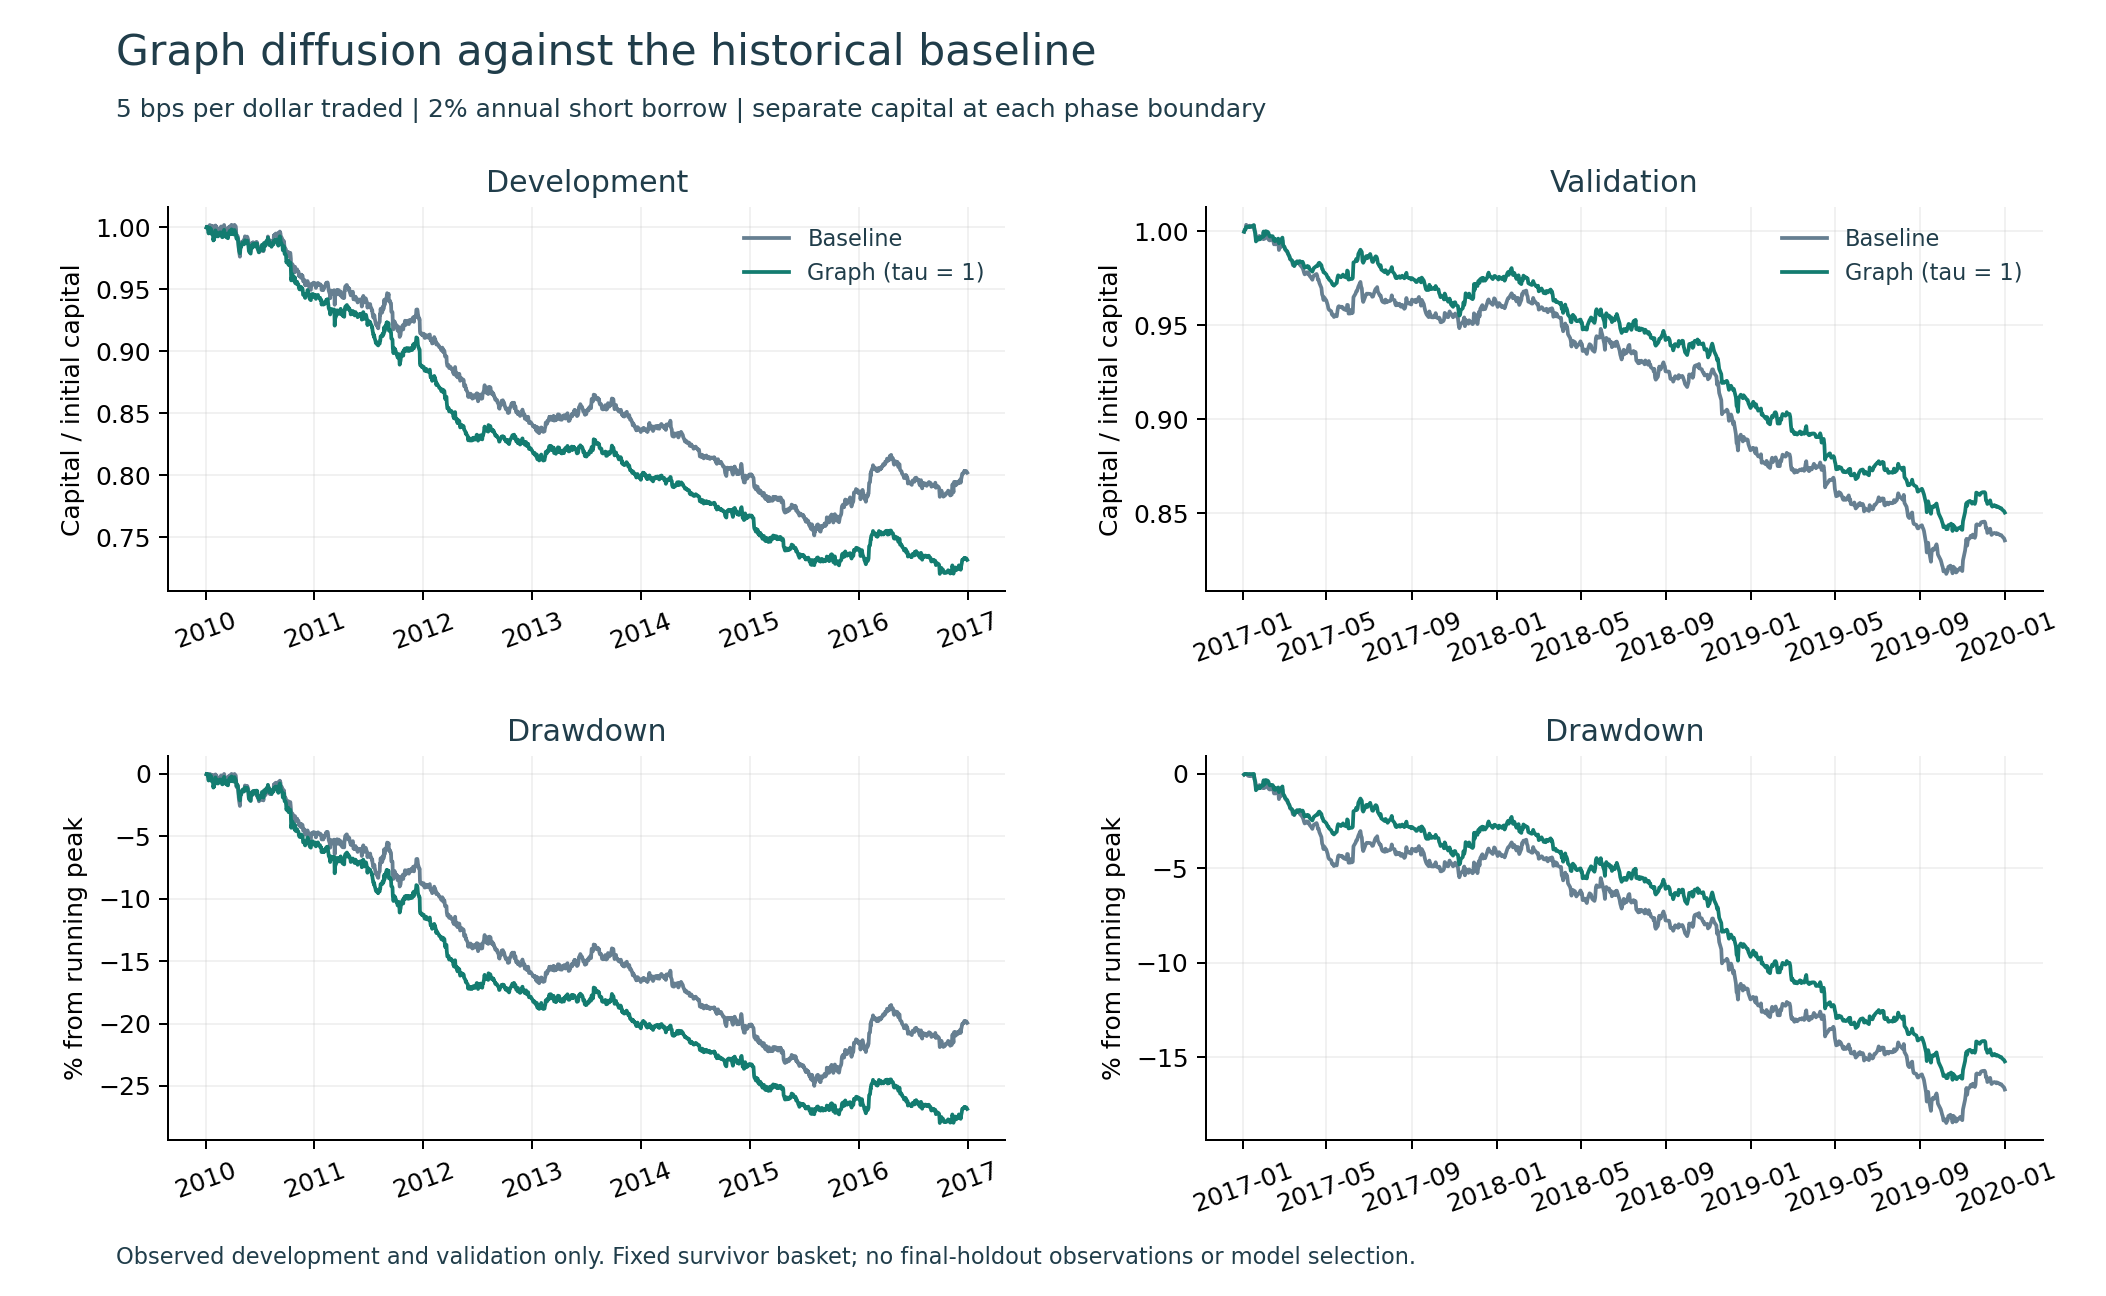

In [3]:
primary = summary[summary.model.isin(["baseline", "graph_tau_1"]) & (summary.trading_cost_bps == 5) & (summary.annual_borrow_rate == .02)]
fields = ["phase", "model", "annualised_return", "annualised_volatility", "maximum_drawdown", "mean_turnover", "mean_gross_exposure"]
display(primary[fields])
for phase in ["development", "validation"]:
    part = primary[primary.phase == phase].set_index("model")
    difference = part.loc["graph_tau_1", "annualised_return"] - part.loc["baseline", "annualised_return"]
    print(f"{phase.title()}: graph-minus-baseline CAGR = {100*difference:+.2f} percentage points")
display(Image(filename=str(output / "06-graph-comparison.png")))

## 3. Check the matched-gross control

A shared 100% ceiling does not imply equal daily gross exposure. The control scales both decision vectors down to their smaller gross exposure before the original execution delay. It preserves the linear neutrality constraints and name caps.

This is a causal diagnostic specific to this project. It is not volatility matching, and it does not establish equal risk. Fama and French (1993), in *Common risk factors in the returns on stocks and bonds*, also remind us that market beta alone does not capture every shared equity risk.

In [4]:
controls = summary[summary.purpose == "matched gross control"]
display(controls[fields])
for phase in ["development", "validation"]:
    b = results[(phase, "baseline_matched")]
    g = results[(phase, "graph_matched")]
    np.testing.assert_allclose(b.ledger.gross_exposure, g.ledger.gross_exposure, atol=1e-12)
    for model, control in [("baseline", b), ("graph_tau_1", g)]:
        original = results[(phase, model)].execution_weights
        assert (control.execution_weights.abs() <= original.abs() + 1e-12).all().all()
    print(f"{phase}: same executed gross exposure; neither control levers up.")

development: same executed gross exposure; neither control levers up.
validation: same executed gross exposure; neither control levers up.


,phase,model,annualised_return,annualised_volatility,maximum_drawdown,mean_turnover,mean_gross_exposure
20,development,baseline_matched,-0.030259,0.029099,-0.242611,0.375366,0.576530
21,development,graph_matched,-0.040540,0.026755,-0.262622,0.375788,0.576530
42,validation,baseline_matched,-0.051621,0.031137,-0.165721,0.366993,0.563812
43,validation,graph_matched,-0.049469,0.027237,-0.152798,0.371165,0.563812


## 4. Account for serial dependence in the paired difference

Politis and Romano (1994) introduce the stationary bootstrap in *The Stationary Bootstrap*. We use it for the daily graph-minus-baseline return series, with expected block length 10 and 5,000 replicates.

Nordman (2009), in *A note on the stationary bootstrap's variance* (Section 2.1, Equation 3), supplies the geometric-block description and an exact finite-sample variance relationship used to check our implementation.

Newey and West (1987), in *A Simple, Positive Semi-Definite, Heteroskedasticity and Autocorrelation Consistent Covariance Matrix*, provide the HAC cross-check with Bartlett weights and ten lags.

These are **pointwise, conditional intervals** for 252 times the mean daily difference, not CAGR intervals. They assume sufficient stationarity and weak dependence; they do not reconstruct prices, refit strategies, or correct survivorship and model-selection bias.

Development: annualised mean difference -1.32 pp; 95% interval [-2.18, -0.47] pp
Validation: annualised mean difference +0.57 pp; 95% interval [-1.16, +2.37] pp


,phase,method,block_or_lags,annualised_mean_difference,annualised_lower,annualised_upper,annualised_standard_error
0,development,stationary bootstrap,5,-0.013207,-0.021653,-0.004698,0.004329
1,development,stationary bootstrap,10,-0.013207,-0.021762,-0.004674,0.004379
2,development,stationary bootstrap,20,-0.013207,-0.022443,-0.004042,0.004652
3,development,Newey-West HAC,10,-0.013207,-0.021509,-0.004905,0.004236
4,validation,stationary bootstrap,5,0.005732,-0.010544,0.023433,0.008704
5,validation,stationary bootstrap,10,0.005732,-0.011584,0.023653,0.008941
6,validation,stationary bootstrap,20,0.005732,-0.011084,0.023648,0.008859
7,validation,Newey-West HAC,10,0.005732,-0.011575,0.023038,0.008830


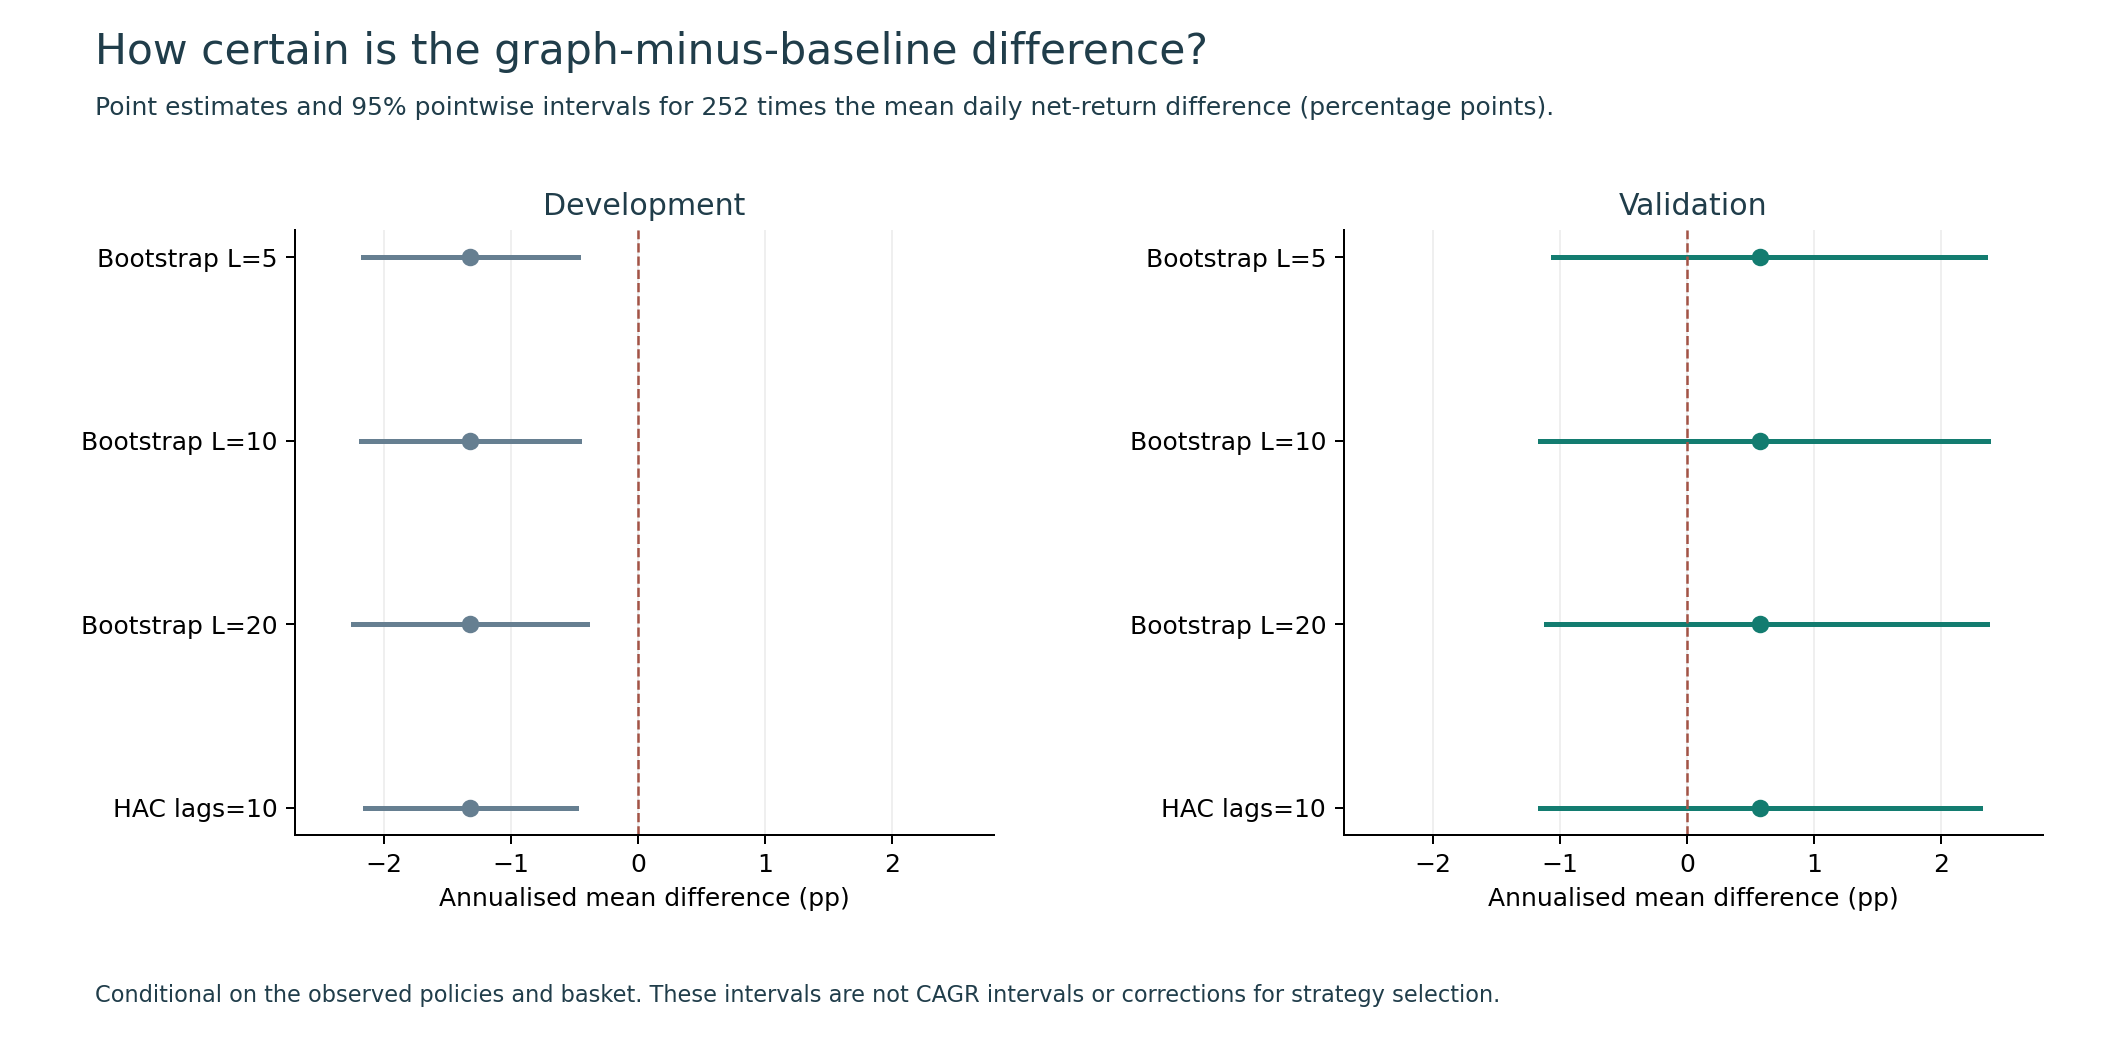

In [5]:
display(uncertainty)
for phase in ["development", "validation"]:
    row = uncertainty[(uncertainty.phase == phase) & (uncertainty.method == "stationary bootstrap") & (uncertainty.block_or_lags == 10)].iloc[0]
    print(f"{phase.title()}: annualised mean difference {100*row.annualised_mean_difference:+.2f} pp; 95% interval [{100*row.annualised_lower:+.2f}, {100*row.annualised_upper:+.2f}] pp")
display(Image(filename=str(output / "08-paired-uncertainty.png")))

## 5. Retain every sensitivity scenario

Diffusion time is tested at 0.5, 1 and 2, with all four trading-fee scenarios. Borrow sensitivity uses 0%, 2% and 5% at 5 bps. Zero trading fees still leave borrow; zero borrow still leaves trading fees.

All three graph candidates underperform the baseline in development and improve its validation CAGR slightly. None produces a positive validation CAGR at any declared fee. These results do not justify choosing a new candidate retrospectively.

trading_cost_bps               0.0       5.0       10.0      20.0
phase       model                                                
development baseline       0.020337 -0.031043 -0.079836 -0.170175
            graph_tau_0.5  0.003115 -0.045356 -0.091484 -0.177163
            graph_tau_1    0.006319 -0.043677 -0.091189 -0.179251
            graph_tau_2    0.012141 -0.038859 -0.087288 -0.176950
validation  baseline      -0.010046 -0.058258 -0.104122 -0.189259
            graph_tau_0.5 -0.004850 -0.052830 -0.098498 -0.183333
            graph_tau_1   -0.004084 -0.052716 -0.098973 -0.184821
            graph_tau_2   -0.006136 -0.054931 -0.101330 -0.187406

annual_borrow_rate           0.00      0.02      0.05
phase       model                                    
development baseline    -0.024931 -0.031043 -0.040139
            graph_tau_1 -0.037730 -0.043677 -0.052528
validation  baseline    -0.052484 -0.058258 -0.066853
            graph_tau_1 -0.046950 -0.052716 -0.061300

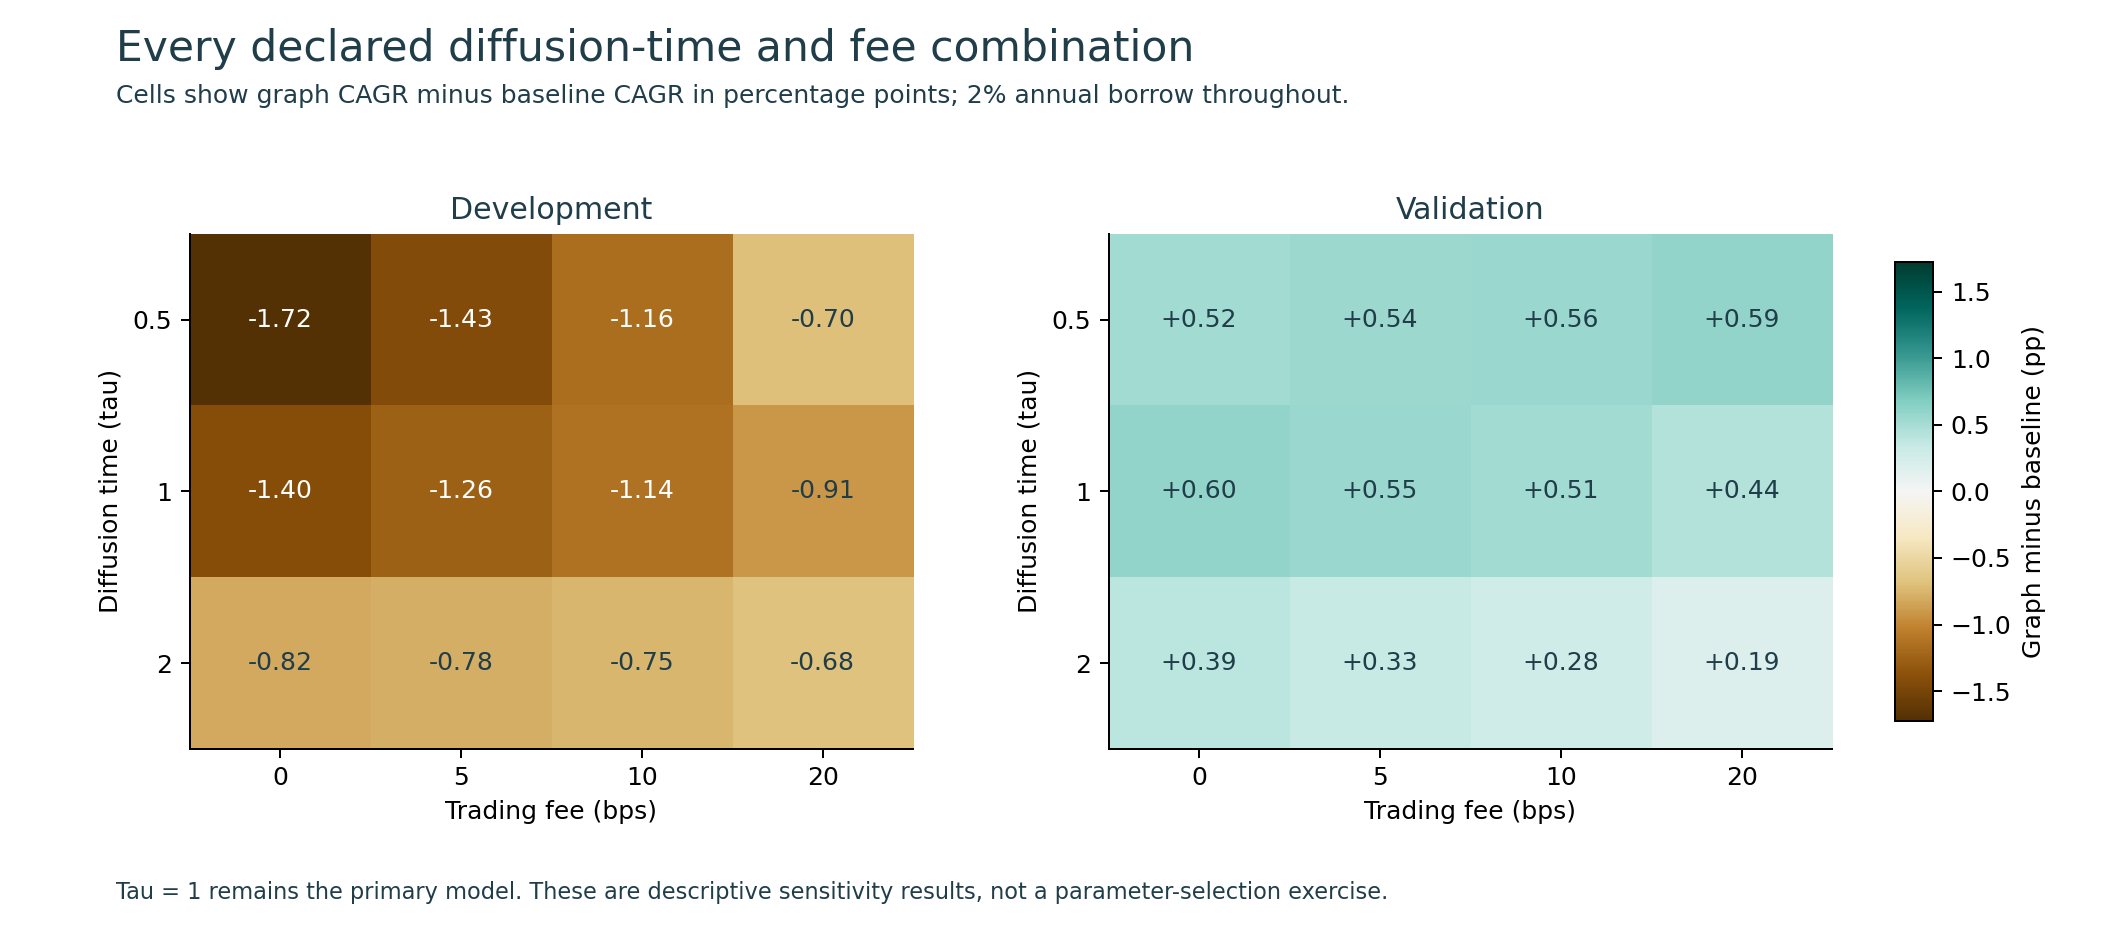

In [6]:
fee_grid = summary[(summary.annual_borrow_rate == .02) & (summary.purpose != "matched gross control")]
display(fee_grid.pivot(index=["phase", "model"], columns="trading_cost_bps", values="annualised_return"))
borrow_grid = summary[summary.model.isin(["baseline", "graph_tau_1"]) & (summary.trading_cost_bps == 5)]
display(borrow_grid.pivot(index=["phase", "model"], columns="annual_borrow_rate", values="annualised_return"))
display(Image(filename=str(output / "07-diffusion-and-costs.png")))

## 6. Reconcile signal contribution and costs

The annualised arithmetic components below reconcile exactly: gross contribution minus trading drag minus borrow drag equals net. Their arithmetic scaling differs from the CAGR measure in the performance table.

The key economic problem is that the observed gross contribution does not finance the declared trading costs. The graph transform changes allocations but does not solve that problem in this sample.

,phase,model,annualised_arithmetic_gross,annualised_trading_drag,annualised_borrow_drag,annualised_arithmetic_net
1,development,baseline,0.026922,0.051666,0.006287,-0.031031
9,development,graph_tau_1,0.012915,0.050954,0.006198,-0.044237
23,validation,baseline,-0.003426,0.049919,0.006112,-0.059457
31,validation,graph_tau_1,0.002401,0.050058,0.006068,-0.053725


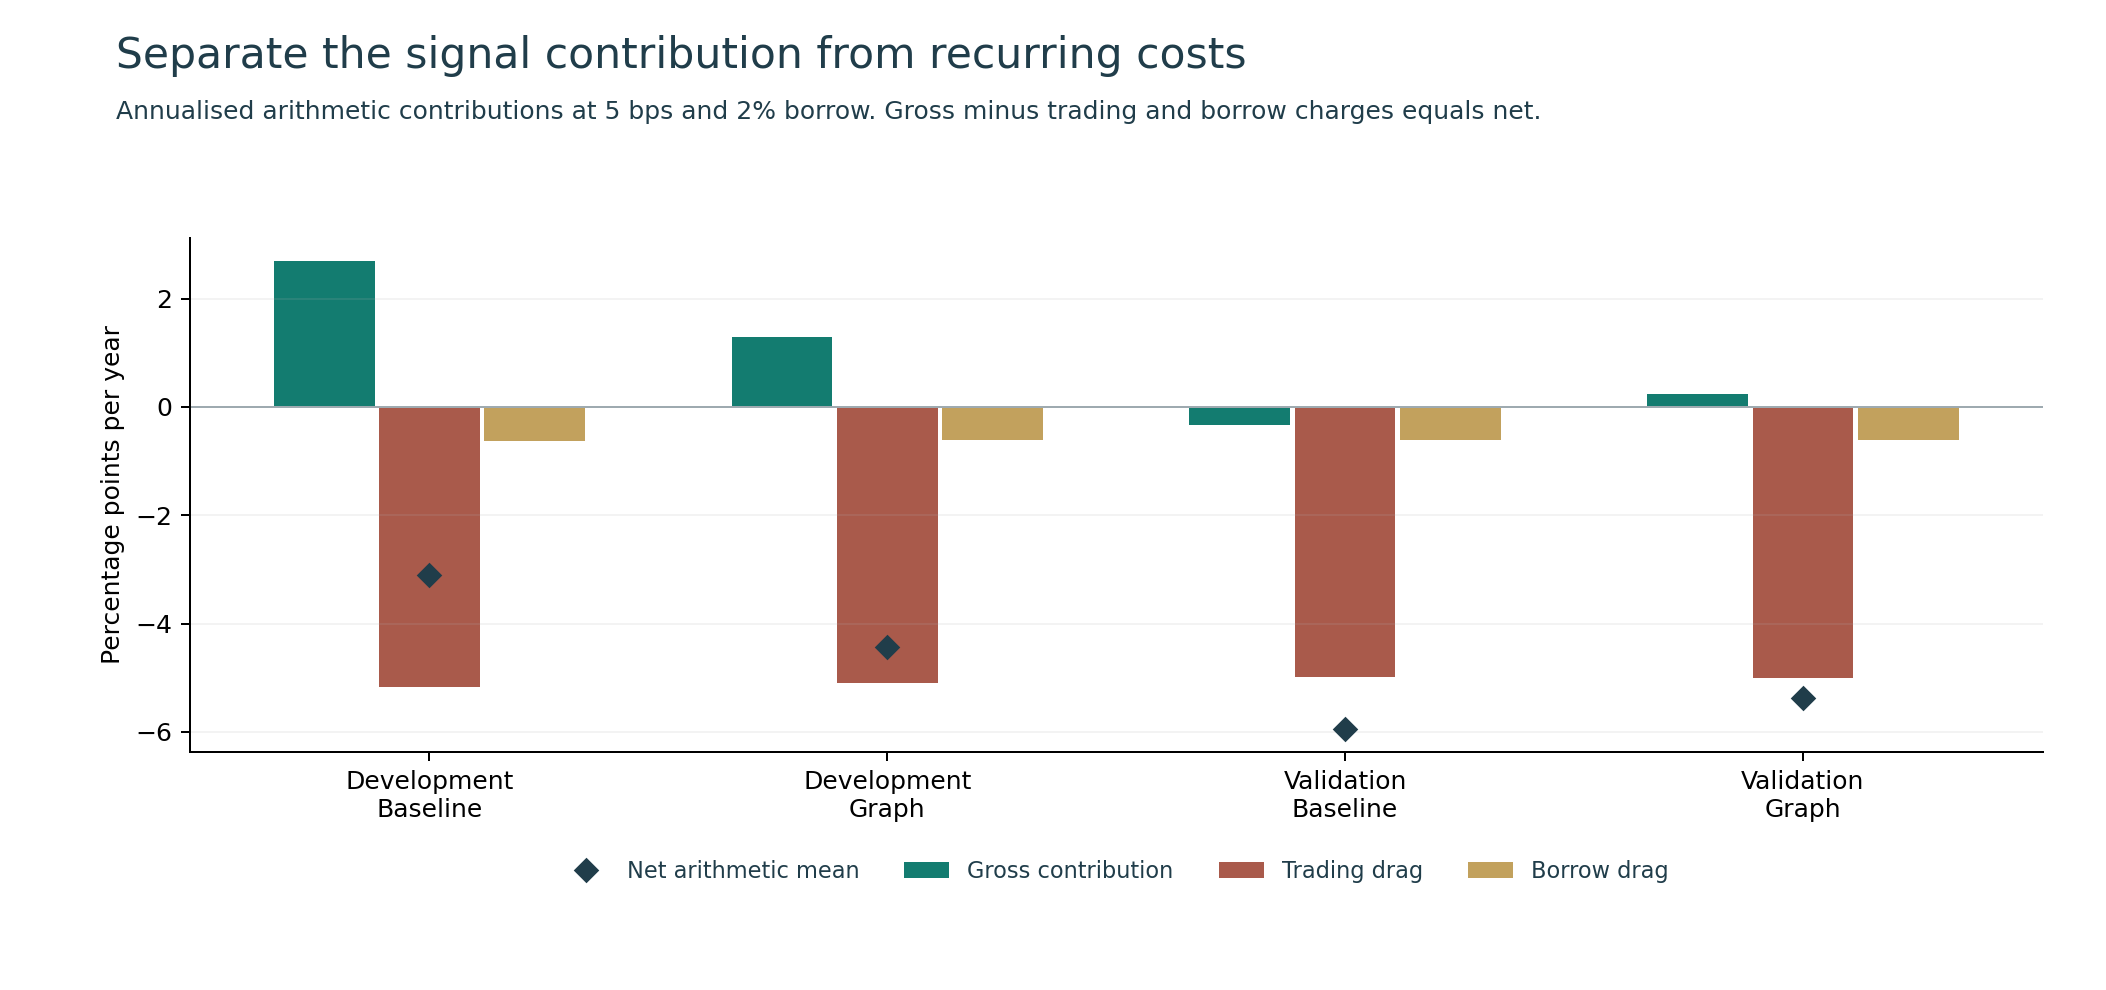

In [7]:
components = ["annualised_arithmetic_gross", "annualised_trading_drag", "annualised_borrow_drag", "annualised_arithmetic_net"]
np.testing.assert_allclose(primary.annualised_arithmetic_net,
    primary.annualised_arithmetic_gross - primary.annualised_trading_drag - primary.annualised_borrow_drag, atol=1e-12)
display(primary[["phase", "model"] + components])
display(Image(filename=str(output / "09-return-and-cost-components.png")))

## 7. Explore the graph and its scores in 3D

Open **`outputs/comparison/Graph-Diffusion-Explorer.html`** in a browser. Rotate, zoom, hover and move through 120 monthly snapshots. The graph is paired with baseline/graph score bars.

Horizontal positions are fixed research-group display coordinates, not estimated financial distances. Edges are drawn on the zero-score plane; node height represents the unconstrained graph score. Exposure projection can subsequently change the sign of a final position. The rendering does not enter the trading model.

The plotted final graph and scores match the actual strategy calculations.


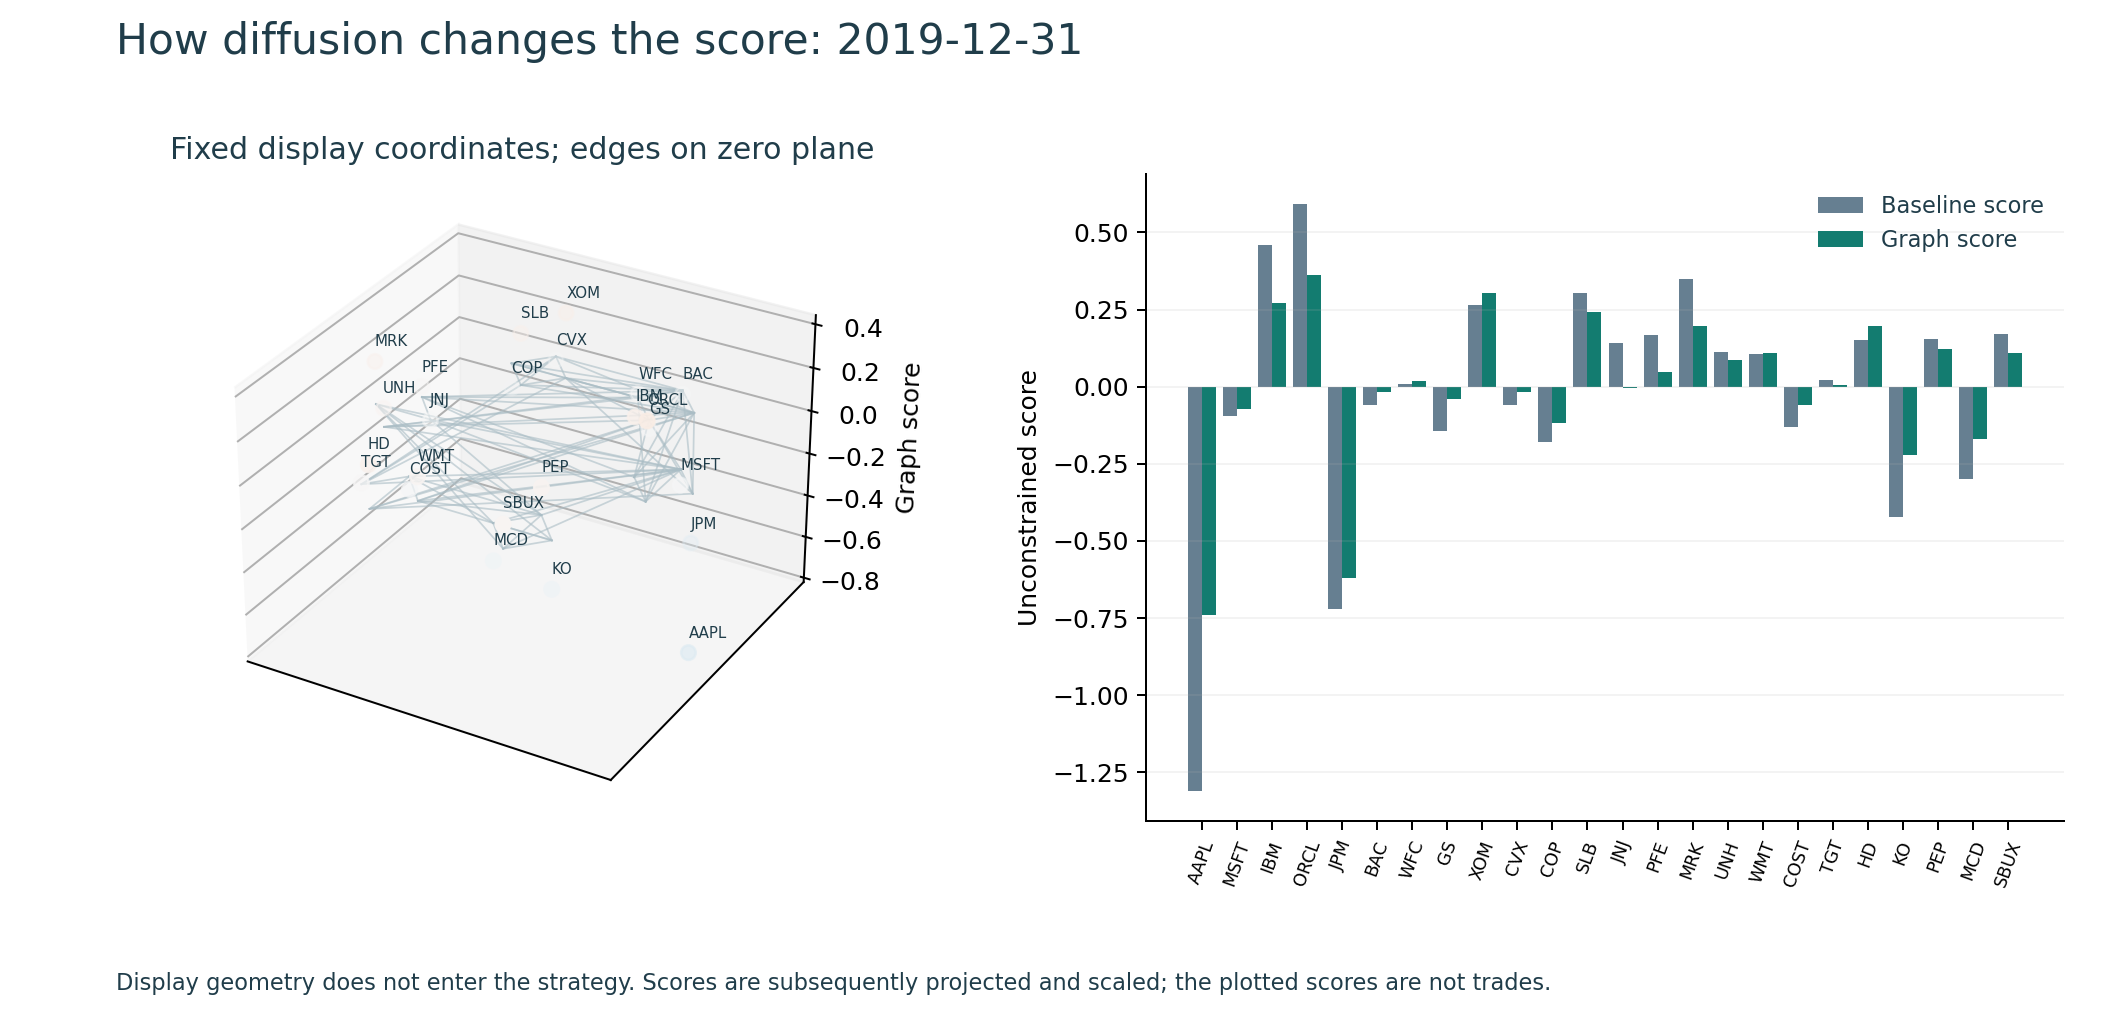

In [8]:
snapshots = json.loads((output / "graph-snapshots.json").read_text())
frames = snapshots["snapshots"]
assert len(frames) == 120 and max(s["date"] for s in frames) < "2020-01-01"
last = frames[-1]
np.testing.assert_allclose(last["adjacency"], decisions.last_graph["adjacency"], atol=1e-12)
np.testing.assert_allclose(last["shock"], decisions.last_graph["shock"], atol=1e-12)
np.testing.assert_allclose(last["graph_score"], decisions.last_graph["smooth"] - decisions.last_graph["shock"], atol=1e-12)
print("The plotted final graph and scores match the actual strategy calculations.")
display(Image(filename=str(output / "10-graph-signal-snapshot.png")))

## 8. Verification and next milestone

The subsequent feature study is now completed in `04-topology-features.ipynb`. It retains the negative trading results, uses a separately frozen feature design and keeps the final holdout reserved. Bailey et al. (2017), in *The probability of backtest overfitting*, explain why an unrestricted sequence of strategy searches needs more than a final holdout to support inference.

The combined working manuscript retains the requested front-matter registers, numbered equations, symbols and code excerpts. Final PDF compilation is deferred. The source package is prepared for an eventual public GitHub repository; no publication has taken place.

In [9]:
check = subprocess.run([sys.executable, "-m", "unittest", "discover", "-s", "tests", "-v"], cwd=ROOT, text=True, capture_output=True)
log = check.stdout + check.stderr
(ROOT / "validation/milestone-3-tests.txt").write_text(log, encoding="utf-8")
print(log)
assert check.returncode == 0


test_circular_continuation_and_constant_series (test_comparison.ComparisonChecks.test_circular_continuation_and_constant_series) ... ok
test_frozen_comparison_protocol_rejects_edits (test_comparison.ComparisonChecks.test_frozen_comparison_protocol_rejects_edits) ... ok
test_hac_matches_bartlett_quadratic_form (test_comparison.ComparisonChecks.test_hac_matches_bartlett_quadratic_form) ... ok
test_matching_gross_preserves_neutrality_and_never_levers_up (test_comparison.ComparisonChecks.test_matching_gross_preserves_neutrality_and_never_levers_up) ... ok
test_paired_mean_interval_is_translation_equivariant (test_comparison.ComparisonChecks.test_paired_mean_interval_is_translation_equivariant) ... ok
test_stationary_bootstrap_matches_exact_mean_variance (test_comparison.ComparisonChecks.test_stationary_bootstrap_matches_exact_mean_variance) ... ok
test_historical_baseline_preserves_milestone_one_rule (test_historical.HistoricalChecks.test_historical_baseline_preserves_milestone_one_rule) .

## Problem-solving record

Read `docs/milestone-decisions.md` for this milestone’s setbacks, design forks, responses and unresolved limitations. These entries are based on retained evidence; negative financial findings are not described as fixed.

## References

Bailey, D.H., Borwein, J.M., Lopez de Prado, M. and Zhu, Q.J. (2017) ‘The probability of backtest overfitting’, *The Journal of Computational Finance*, 20(4), pp. 39–69. doi: [10.21314/JCF.2016.322](https://doi.org/10.21314/JCF.2016.322).

Fama, E.F. and French, K.R. (1993) ‘Common risk factors in the returns on stocks and bonds’, *Journal of Financial Economics*, 33(1), pp. 3–56. doi: [10.1016/0304-405X(93)90023-5](https://doi.org/10.1016/0304-405X(93)90023-5).

Kondor, R.I. and Lafferty, J.D. (2002) ‘Diffusion Kernels on Graphs and Other Discrete Input Spaces’, in *Proceedings of the 19th International Conference on Machine Learning*, pp. 315–322. doi: [10.5555/645531.655996](https://doi.org/10.5555/645531.655996).

Newey, W.K. and West, K.D. (1987) ‘A Simple, Positive Semi-Definite, Heteroskedasticity and Autocorrelation Consistent Covariance Matrix’, *Econometrica*, 55(3), pp. 703–708. doi: [10.2307/1913610](https://doi.org/10.2307/1913610).

Nordman, D.J. (2009) ‘A note on the stationary bootstrap's variance’, *The Annals of Statistics*, 37(1), pp. 359–370. doi: [10.1214/07-AOS567](https://doi.org/10.1214/07-AOS567).

Politis, D.N. and Romano, J.P. (1994) ‘The Stationary Bootstrap’, *Journal of the American Statistical Association*, 89(428), pp. 1303–1313. doi: [10.1080/01621459.1994.10476870](https://doi.org/10.1080/01621459.1994.10476870).

White, H. (2000) ‘A Reality Check for Data Snooping’, *Econometrica*, 68(5), pp. 1097–1126. doi: [10.1111/1468-0262.00152](https://doi.org/10.1111/1468-0262.00152).